# Step 1: Frame the problem and first look

- What I am predicting ? The prices of Houses
- Who would use this prediction, and for what decision? The buyer, the seller just to get a rough estimate of the price they are gonna go with, and maybe for another ML begineer learners

In [80]:
import pandas as pd
df_train = pd.read_csv('data/train.csv')


In [81]:
print(df_train.shape)
print(df_train.info())


(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [82]:
print(df_train.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [83]:
print(f"Number of columns: {len(df_train.columns)}")

Number of columns: 81


In [84]:
object_columns = [col for col in df_train.columns if df_train[col].dtype == 'object']
print(f"Number of categorical columns: {len(object_columns)}")

numeric_columns = [col for col in df_train.columns if df_train[col].dtype == 'int64' or df_train[col].dtype == 'float64']
print(f"Number of numeric columns : {len(numeric_columns)}")

Number of categorical columns: 43
Number of numeric columns : 38


In [85]:
null_counts = df_train.isnull().sum()
print(type(null_counts))
print(null_counts[null_counts > 0].sort_values(ascending = False))


<class 'pandas.core.series.Series'>
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


### Missing values: Group A vs Group B

**Rule:** If `data_description.txt` lists `NA` as a defined category (e.g. "No Garage") → **Group A**: the feature genuinely doesn't exist, so fill with a placeholder like `"None"`, not a guess. If `NA` isn't documented at all → **Group B**: every row should have a real value, so it's just unrecorded — fill statistically (median/most frequent).

**Group A:** PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType/Finish/Qual/Cond, BsmtFinType1/2, BsmtExposure, BsmtQual, BsmtCond
*(+ GarageYrBlt by inference — no documented NA, but missing count matches the other Garage columns)*

**Group B:** LotFrontage, Electrical

**Unclear — needs a manual check:** MasVnrType/Area. `"None"` is already a valid category for MasVnrType, but NaN itself isn't documented, so the rule can't decide it alone.

### Check: is MasVnrType's NaN really "no veneer"?

Filtering to rows where MasVnrType is null and looking at MasVnrArea there — if it's ~0 across the board, that's evidence these are unlabeled "no veneer" houses, not truly unrecorded, and both columns move to Group A.

In [86]:
filtered = df_train[df_train['MasVnrType'].isnull()]
print(filtered['MasVnrArea'])
bools = filtered['MasVnrArea'] == 0
print(bools.all())



1       0.0
3       0.0
5       0.0
8       0.0
9       0.0
       ... 
1454    0.0
1455    0.0
1457    0.0
1458    0.0
1459    0.0
Name: MasVnrArea, Length: 872, dtype: float64
False


In [87]:
print(len(filtered[~bools]))
print(filtered[~bools]['MasVnrArea'])

13
234       NaN
529       NaN
624     288.0
650       NaN
773       1.0
936       NaN
973       NaN
977       NaN
1230      1.0
1243      NaN
1278      NaN
1300    344.0
1334    312.0
Name: MasVnrArea, dtype: float64


**Result:** 859/872 (98.5%) of MasVnrType-null rows have MasVnrArea == 0 — consistent with "no veneer." The remaining 13 are mixed (8 also NaN, 5 have real nonzero area) — likely genuine data gaps, but negligible (<1% of all rows). **Decision:** treat MasVnrType/Area as Group A — fill with `"None"` / `0`.

# Step 2: EDA on Target (SalesPrice)

In [88]:
df_train['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

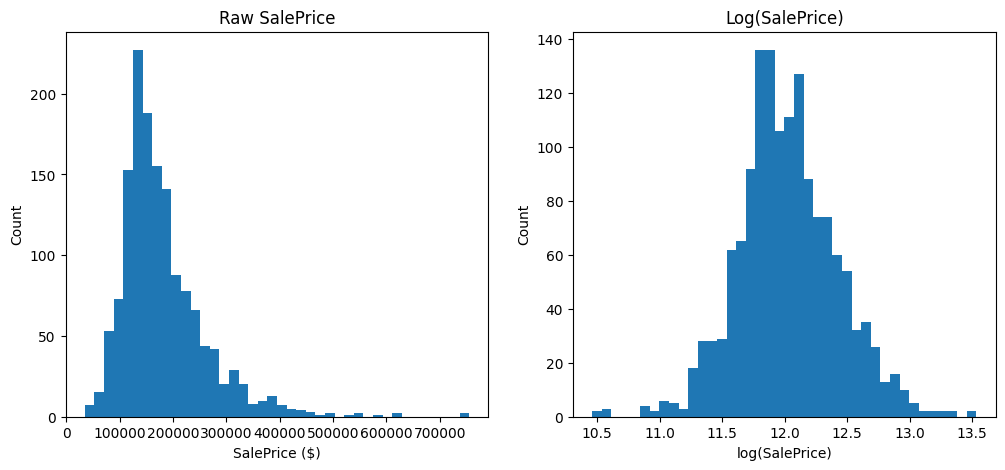

In [89]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_train['SalePrice'], bins=40)
axes[0].set_title('Raw SalePrice')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log(df_train['SalePrice']), bins=40)
axes[1].set_title('Log(SalePrice)')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('Count')

plt.show()

In [90]:
print("Raw skew:", df_train['SalePrice'].skew())
print("Log skew:", np.log(df_train['SalePrice']).skew())

Raw skew: 1.8828757597682129
Log skew: 0.12133506220520406


Raw SalePrice skew = 1.88 (highly skewed), log(SalePrice) skew = 0.12 (near-symmetric). A few very expensive homes stretch a long right tail in raw dollars, which can dominate a model's loss and pull predictions toward those outliers instead of fitting the typical house well. Training on log(SalePrice) evens this out — errors become roughly proportional (%) rather than absolute ($), which better reflects what actually matters for pricing, and matches the Kaggle 
competition's own scoring metric.


In [91]:
df_train[numeric_columns].corr()['SalePrice'].sort_values(ascending = False)[:10]

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Strongest correlates with SalePrice: OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61). Matches intuition — quality, size, and garage/basement capacity drive price.

# Step 3: Train / validation split


note: splitting before any preprocessing to avoid leakage, same pattern as Iris

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
df_train['SalePrice_log'] = np.log(df_train['SalePrice'])
X = df_train.drop(columns = ['SalePrice', 'SalePrice_log'])
y = df_train['SalePrice_log']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [94]:
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (1168, 80)
X_valid shape: (292, 80)
y_train shape: (1168,)
y_valid shape: (292,)


In [95]:
print(X_train.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [96]:
'log(SalePrice)' in X_train.columns

False

In [97]:
df_train = df_train.drop(columns = ['log(SalePrice)'], errors='ignore')
X = df_train.drop(columns=['SalePrice', 'SalePrice_log'], errors='ignore')  #dropping leftoever log(SalePrice) and SalePrice
y = df_train['SalePrice_log']
X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=42)

In [98]:
print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_valid shape: {y_valid.shape}")

X_train shape: (1168, 80)
X_valid shape: (292, 80)
y_train shape: (1168,)
y_valid shape: (292,)


In [99]:
'log(SalePrice)' in X_train.columns

False

In [100]:
'SalePrice' in X_train.columns

False

In [101]:
'SalePrice_log' in X_train.columns

False